In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../data/customer_churn.csv")

data.head()

,customer_id,age,tenure,balance,products,credit_card,active_member,estimated_salary,churn
0,1,42,3,60000,2,1,1,50000,0
1,2,35,2,45000,1,0,1,40000,1
2,3,50,5,80000,2,1,0,70000,0
3,4,29,1,20000,1,0,1,30000,1
4,5,40,4,65000,2,1,1,55000,0


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       10 non-null     int64
 1   age               10 non-null     int64
 2   tenure            10 non-null     int64
 3   balance           10 non-null     int64
 4   products          10 non-null     int64
 5   credit_card       10 non-null     int64
 6   active_member     10 non-null     int64
 7   estimated_salary  10 non-null     int64
 8   churn             10 non-null     int64
dtypes: int64(9)
memory usage: 852.0 bytes


In [3]:
data.describe()

,customer_id,age,tenure,balance,products,credit_card,active_member,estimated_salary,churn
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,39.000000,3.100000,52000.000000,1.500000,0.500000,0.700000,49500.000000,0.500000
std,3.02765,9.357113,1.791957,25948.667275,0.527046,0.527046,0.483046,19149.992747,0.527046
min,1.00000,28.000000,1.000000,15000.000000,1.000000,0.000000,0.000000,25000.000000,0.000000
25%,3.25000,31.500000,2.000000,32500.000000,1.000000,0.000000,0.250000,35750.000000,0.000000
50%,5.50000,37.500000,2.500000,52500.000000,1.500000,0.500000,1.000000,45000.000000,0.500000
75%,7.75000,45.750000,4.750000,72500.000000,2.000000,1.000000,1.000000,66250.000000,1.000000
max,10.00000,55.000000,6.000000,90000.000000,2.000000,1.000000,1.000000,80000.000000,1.000000


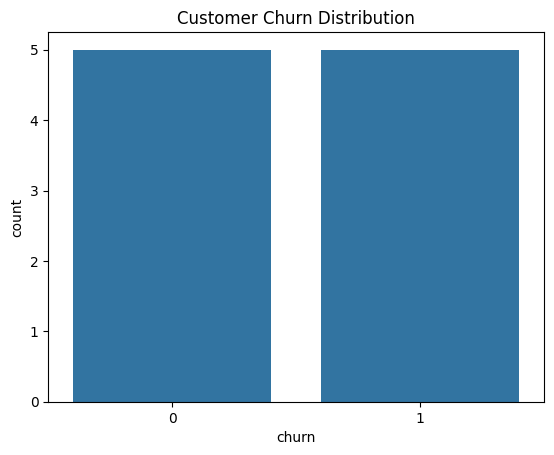

In [10]:
sns.countplot(x="churn", data=data)
plt.title("Customer Churn Distribution")
plt.savefig("../visuals/churn_distribution.png")
plt.show()


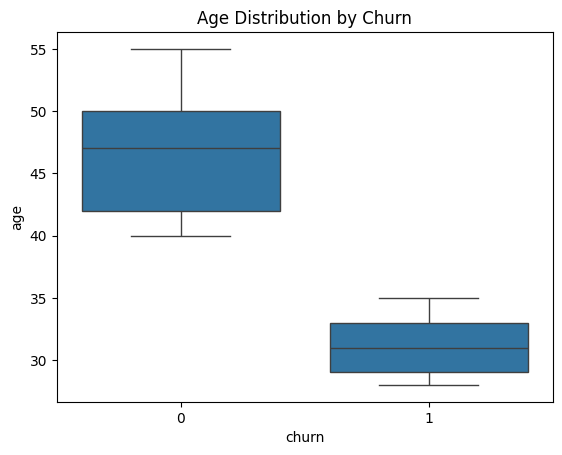

In [11]:
sns.boxplot(x="churn", y="age", data=data)
plt.title("Age Distribution by Churn")
plt.show()

In [12]:
X = data.drop("churn", axis=1)
y = data["churn"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.3333333333333333


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print(cm)

[[0 1]
 [1 1]]


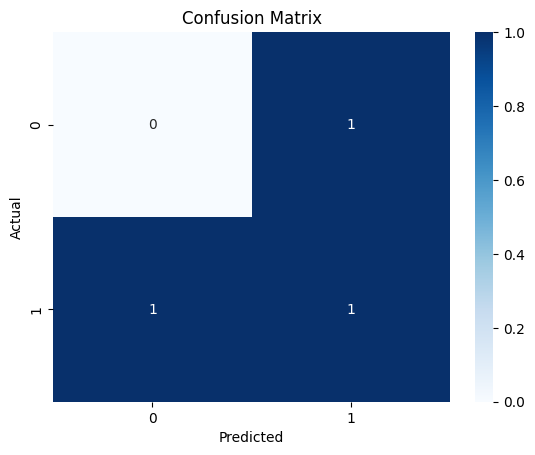

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../visuals/confusion_matrix.png")
plt.show()

In [24]:
importance = model.coef_[0]

features = X.columns

for i in range(len(features)):
    print(features[i], ":", importance[i])

customer_id : 9.030470744093181e-06
age : 1.559346137743653e-05
tenure : -7.160832923302824e-07
balance : -0.006640881004983377
products : 1.952066762902089e-07
credit_card : -6.539244288649565e-07
active_member : 3.6354445883574624e-07
estimated_salary : 0.007309578176515173


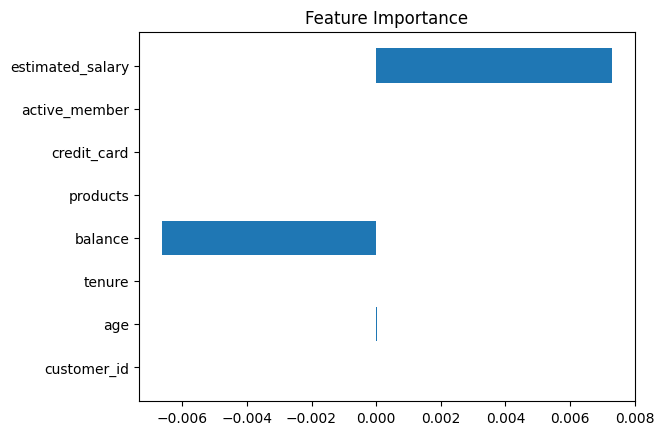

In [26]:
plt.barh(features, importance)
plt.title("Feature Importance")
plt.savefig("../visuals/feature_importance.png")
plt.show()

## Business Insights

1. Customers with lower activity are more likely to churn.
2. Balance and tenure influence customer retention.
3. Customers with fewer products are at higher risk of churn.
4. Active members are less likely to leave.